# Patricia ARC-AGI-3 T4 Paper Prize representative submission v48 policy=static

Representative full competition rerun for the final Paper Prize interaction-policy package.

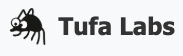

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "saltb0x/arc3-vllm-wheelhouse-v0271-cu129"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

In [ ]:
# Extract the exact locally-tested Patricia harness; do not patch the older Kaggle bundle.
import base64
import io
import shutil
import zipfile
PATRICIA_HARNESS_REPO = WORKING_DIR / "patricia-arc3-inference"
shutil.rmtree(PATRICIA_HARNESS_REPO, ignore_errors=True)
PATRICIA_HARNESS_REPO.mkdir(parents=True, exist_ok=True)
_archive = base64.b64decode('...')
with zipfile.ZipFile(io.BytesIO(_archive), "r") as _zf:
    _zf.extractall(PATRICIA_HARNESS_REPO)
subprocess.check_call([sys.executable, '-m', 'py_compile',
    str(PATRICIA_HARNESS_REPO / 'inference/agent/repair_ledger.py'),
    str(PATRICIA_HARNESS_REPO / 'inference/agent/transition_signature.py'),
    str(PATRICIA_HARNESS_REPO / 'inference/agent/navigation_hint.py'),
    str(PATRICIA_HARNESS_REPO / 'inference/agent/state_match_hint.py'),
    str(PATRICIA_HARNESS_REPO / 'inference/agent/resource_hint.py'),
    str(PATRICIA_HARNESS_REPO / 'inference/agent/interaction_frontier.py'),
    str(PATRICIA_HARNESS_REPO / 'inference/agent/host_evidence.py'),
    str(PATRICIA_HARNESS_REPO / 'inference/agent/tool_agent.py'),
    str(PATRICIA_HARNESS_REPO / 'inference/framework/solver.py')])
os.environ["PYTHONPATH"] = str(PATRICIA_HARNESS_REPO) + os.pathsep + os.environ.get("PYTHONPATH", "")
print("Patricia embedded harness ready:", PATRICIA_HARNESS_REPO)


## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Patricia T4/AWQ serving transform: preserve Tufa's integration, replace only runtime/model/hardware.
os.environ["KAGGLE_GPU_TYPE"] = "t4"
os.environ["KAGGLE_GPU_COUNT"] = "2"
os.environ["LOCAL_ANALYZER_MAX_OUTPUT"] = "512"
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    command = command.replace("driessmit1'\nWHEELHOUSE_SLUG = 'arc3-vllm-h100-wheelhouse-v3", "saltb0x'\nWHEELHOUSE_SLUG = 'arc3-vllm-wheelhouse-v0271-cu129")
    command = command.replace("MODEL_OWNER = 'driessmit1'", "MODEL_OWNER = 'bachhg'")
    command = command.replace("MODEL_SLUG = 'vrfai-qwen3-6-27b-fp8-hf-snapshot'", "MODEL_SLUG = 'qwen3-6-27b-awq'")
    command = command.replace("SERVED_MODEL_NAME = 'vrfai/Qwen3.6-27B-FP8'", "SERVED_MODEL_NAME = 'Qwen3.6-27B-AWQ'")
    command = command.replace("VLLM_MAX_MODEL_LEN = 65536", "VLLM_MAX_MODEL_LEN = 8192")
    command = command.replace("ANALYZER_CONTEXT_WINDOW = 32768", "ANALYZER_CONTEXT_WINDOW = 8192")
    command = command.replace("'LOCAL_ANALYZER_YIELD_SECONDS': '60'", "'LOCAL_ANALYZER_YIELD_SECONDS': '0'")
    command = command.replace("VLLM_TENSOR_PARALLEL_SIZE = 1", "VLLM_TENSOR_PARALLEL_SIZE = 2")
    command = command.replace("STAMP_TEXT = 'vllm==0.19.0 torch==2.10.0 flashinfer==0.6.6\\n'", "STAMP_TEXT = 'vllm==0.27.1 torch==2.13.0 compressed-tensors==0.17.0\\n'")
    command = command.replace("MODEL_PATH = resolve_kaggle_dataset_path(MODEL_OWNER, MODEL_SLUG)", "MODEL_PATH = next((p.parent for p in Path('/kaggle/input/models').rglob('config.json') if 'qwen3-6-27b-awq' in str(p).lower()), None)\nif MODEL_PATH is None: raise FileNotFoundError('Qwen3.6 AWQ model source not found')")
    command = command.replace("            'TRANSFORMERS_NO_TORCHVISION': '1',\n", "")
    command = command.replace("            'VLLM_NO_USAGE_STATS': '1',", "            'VLLM_NO_USAGE_STATS': '1',\n            'VLLM_LOGGING_LEVEL': 'WARNING',\n            'VLLM_LOGGING_COLOR': '0',\n            'VLLM_USE_FLASHINFER_SAMPLER': '0',\n            'PYTHONUTF8': '1',\n            'PYTHONIOENCODING': 'utf-8',\n            'LANG': 'C.UTF-8',\n            'LC_ALL': 'C.UTF-8',")
    command = command.replace("        str(VLLM_MAX_MODEL_LEN),\n    ]", "        str(VLLM_MAX_MODEL_LEN),\n        '--enforce-eager',\n        '--dtype', 'half',\n        '--gpu-memory-utilization', '0.90',\n        '--max-num-seqs', '1',\n        '--max-num-batched-tokens', '8192',\n    ]")
    command = command.replace("    'MULTIMODAL_UPSCALE': '4',", "    'MULTIMODAL_UPSCALE': '4',\n    'MULTIMODAL_STYLE': 'outline',")
    print("taaf.kaggle: transformed T4 setup command", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    env = _command_env()
    os.environ.update(env)

# The setup runs in a subprocess, so explicitly put its wheelhouse target first
# in this notebook process before importing arcengine/Pillow or the agent.
vllm_site = "/kaggle/working/vllm-site-packages"
if os.path.isdir(vllm_site):
    while vllm_site in sys.path:
        sys.path.remove(vllm_site)
    sys.path.insert(0, vllm_site)
    current_pythonpath = os.environ.get("PYTHONPATH", "")
    os.environ["PYTHONPATH"] = vllm_site + (os.pathsep + current_pythonpath if current_pythonpath else "")
    print("taaf.kaggle: prepended runtime site-packages:", vllm_site, flush=True)
    # Kaggle may have imported its system Pillow earlier; sys.path alone cannot replace cached modules.
    for _name in [n for n in list(sys.modules) if n == "PIL" or n.startswith("PIL.")]:
        del sys.modules[_name]
    import PIL as _pil_runtime
    _pil_path = str(Path(_pil_runtime.__file__).resolve())
    print("taaf.kaggle: Pillow runtime:", _pil_path, getattr(_pil_runtime, "__version__", "unknown"), flush=True)
    if not _pil_path.startswith(vllm_site):
        raise RuntimeError(f"Pillow did not reload from wheelhouse: {_pil_path}")

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)
# Prefer Patricia's embedded newer harness over the older source bundle.
if str(PATRICIA_HARNESS_REPO) in sys.path:
    sys.path.remove(str(PATRICIA_HARNESS_REPO))
sys.path.insert(0, str(PATRICIA_HARNESS_REPO))
pth_existing = pth_path.read_text(encoding='utf-8') if pth_path.exists() else ''
pth_path.write_text(str(PATRICIA_HARNESS_REPO) + '\n' + pth_existing, encoding='utf-8')

# T4/AWQ anti-stall compatibility patch, applied identically to both A/B arms.
_tool_agent_path = PATRICIA_HARNESS_REPO / "inference" / "agent" / "tool_agent.py"
_tool_agent_src = _tool_agent_path.read_text(encoding="utf-8")
_anti_stall_anchor = '        valid_actions = list(_normalize_valid_actions(self._current_valid_actions))\n'
_anti_stall_insert = (
    '        _anti_stall_has_action = bool(re.search(r"(?<!\\w)action\\s*\\(", code))\n'
    '        if _anti_stall_has_action:\n'
    '            self._anti_stall_inspection_streak = 0\n'
    '        else:\n'
    '            _anti_stall_streak = int(getattr(self, "_anti_stall_inspection_streak", 0)) + 1\n'
    '            self._anti_stall_inspection_streak = _anti_stall_streak\n'
    '            if _anti_stall_streak >= 2 and valid_actions:\n'
    '                _anti_stall_index = int(getattr(self, "_anti_stall_probe_index", 0))\n'
    '                _anti_stall_probe = valid_actions[_anti_stall_index % len(valid_actions)]\n'
    '                self._anti_stall_probe_index = _anti_stall_index + 1\n'
    '                self._anti_stall_inspection_streak = 0\n'
    '                code += (\n'
    '                    "\\n# T4 anti-stall compatibility probe after one inspection-only call.\\n"\n'
    '                    f"# T4_ANTI_STALL_FORCED_ACTION={_anti_stall_probe}\\n"\n'
    '                    f"print(\\"ANTI_STALL_PROBE: {_anti_stall_probe}\\")\\n"\n'
    '                    f"action([{_anti_stall_probe!r}])\\n"\n'
    '                )\n'
    '                try:\n'
    '                    compile(code, "<python_tool_anti_stall>", "exec")\n'
    '                except SyntaxError as exc:\n'
    '                    return _ToolDispatchResult(json.dumps({"error": f"Anti-stall probe injection failed: {exc}"}, indent=2))\n'
)
if _anti_stall_anchor not in _tool_agent_src:
    raise RuntimeError("T4 anti-stall anchor missing from tool_agent.py")
if '_anti_stall_probe = valid_actions[_anti_stall_index % len(valid_actions)]' not in _tool_agent_src:
    _tool_agent_src = _tool_agent_src.replace(_anti_stall_anchor, _anti_stall_anchor + _anti_stall_insert, 1)
    _tool_agent_path.write_text(_tool_agent_src, encoding="utf-8")
print("taaf.kaggle: T4 anti-stall compatibility patch ready", flush=True)


In [ ]:
# Fail before inference if the embedded repair harness is not the tested version.
from inference.agent import repair_ledger as _rl
from inference.agent.transition_signature import summarize_transition as _sig
from inference.agent.host_evidence import ingest_action_evidence as _ingest
from inference.agent.navigation_hint import summarize_navigation as _nav
_state = _rl.empty_ledger()
_state = _rl.merge_update(_state, {"rule_bank": "R1 VERIFIED(s2) IF LEFT => x-1\nR2 VERIFIED(s3) IF RIGHT => x+1"})
_state = _rl.merge_update(_state, {"rule_bank": "R1 VERIFIED(s2,s8) scope=free IF LEFT => x-1", "counterexamples": "C1 s8: predicted move; actual self-loop"})
assert "R2 VERIFIED(s3)" in _state["rule_bank"]
assert _state["counterexamples"].count("C1 ") == 1
assert _sig(((0,1),(0,0)), ((1,0),(0,0)))["cells"] == 2
_h1 = _sig(((0,1),(0,0)), ((1,0),(0,0)))
_h2 = _sig(((1,0),(0,0)), ((0,1),(0,0)))
assert "c1:n1:d[0,-1]" in _h1["motions"]
_e1 = {"executed": True, "action_num": 1, "level": 1, "action_display": "UP", "executed_actions": ["UP"], "board_changed": True, "transition_signature": _h1}
_e2 = {"executed": True, "action_num": 2, "level": 1, "action_display": "DOWN", "executed_actions": ["DOWN"], "board_changed": True, "transition_signature": _h2}
_host = _ingest(_rl.empty_ledger(), _e1)
_host = _ingest(_host, _e2)
assert _host["rule_bank"] == ""
assert "HOST_EVIDENCE" in _host["level_log"]
assert "action=UP" in _host["level_log"] and "action=DOWN" in _host["level_log"]
assert "motions=['c1:n1:d[0,-1]']" in _host["level_log"]
_nb = [[3]*12 for _ in range(12)]
_na = [row[:] for row in _nb]
for _r,_c,_v in ((8,4,9),(8,5,9),(9,4,12),(9,5,12)): _nb[_r][_c]=_v
for _r,_c,_v in ((6,4,9),(6,5,9),(7,4,12),(7,5,12)): _na[_r][_c]=_v
for _r in (2,3):
    for _c in (4,5): _nb[_r][_c]=_na[_r][_c]=5
_nh = _nav(_nb,_na)
assert _nh["lattice_step"] == 2 and _nh["footprint_cells"] == 4 and _nh["frontiers"]
_e_nav = dict(_e1); _e_nav["navigation_hint"] = _nh
_host_nav = _ingest(_rl.empty_ledger(), _e_nav)
assert "HOST_NAV" in _host_nav["level_log"] and "frontiers=" in _host_nav["level_log"]
from inference.agent import tool_agent as _ta
assert "rule_bank" in _ta._empty_world_model()
assert "goal_procedure" in _ta._empty_world_model()
_rule_shapes = _rl.merge_update(_rl.empty_ledger(), {"rule_bank": ["R1: UP moves object up 5", "R2: static"]})
_rule_shapes = _rl.merge_update(_rule_shapes, {"rule_bank": ["R1: UP/DOWN move object vertically 5"]})
assert _rule_shapes["rule_bank"].count("R1:") == 1
assert "UP/DOWN" in _rule_shapes["rule_bank"] and "R2: static" in _rule_shapes["rule_bank"]
import inspect as _inspect
assert "_patricia_evidence_inspection_count" in _inspect.getsource(_ta.ToolAgent._run_python_tool)
from pathlib import Path as _Path
_action_probe = _ta.ToolAgent(model="fake/model", base_url="http://127.0.0.1:1/v1", provider="vllm")
_action_probe._current_valid_actions = ["UP", "DOWN"]
_action_probe._patricia_action_only = True
_action_tools = _action_probe._tools(_Path("/tmp/patricia-action-tool-selftest.json"))
assert len(_action_tools) == 1 and _action_tools[0]["function"]["name"] == "act"
assert _action_tools[0]["function"]["parameters"]["properties"]["action"]["enum"] == ["UP", "DOWN"]
assert _action_tools[0]["function"]["parameters"]["properties"]["repeat"]["maximum"] == 6
assert _action_tools[0]["function"]["parameters"]["properties"]["sequence"]["maxItems"] == 8
assert "blocked edge from this exact state" in _inspect.getsource(_ta.ToolAgent._build_user_prompt)
assert _ta._request_tool_choice(_action_tools) == "required"
_mouse_probe = _ta.ToolAgent(model="fake/model", base_url="http://127.0.0.1:1/v1", provider="vllm")
_mouse_state = _Path("/tmp/patricia-mouse-selftest.json")
_mouse_probe._ensure_session(_mouse_state)
_mouse_probe._current_valid_actions = ["MOUSE"]
_mouse_probe._patricia_action_only = True
_mouse_probe._patricia_current_interventions = {("MOUSE", 1, 1): {"row": 1, "col": 1}}
_mouse_tools = _mouse_probe._tools(_mouse_state)
assert _mouse_tools[0]["function"]["parameters"]["required"] == ["action", "candidate_index", "world_model"]
assert _mouse_tools[0]["function"]["parameters"]["properties"]["candidate_index"]["maximum"] == 16
_mouse_probe._patricia_current_interventions = {}
_mouse_fallback_tools = _mouse_probe._tools(_Path("/tmp/patricia-mouse-fallback-selftest.json"))
assert _mouse_fallback_tools[0]["function"]["parameters"]["required"] == ["action", "world_model"]
assert 'candidate_index = arguments.get("candidate_index")' in _inspect.getsource(_ta.ToolAgent._run_action_tool)
assert "Action-only exploratory MOUSE must use candidate_index" in _inspect.getsource(_ta.ToolAgent._run_action_tool)
assert "HOST_INTERACTION_MENU:" in _inspect.getsource(_ta.ToolAgent.analyze)
assert "candidate_index from the visible HOST_INTERACTION menu is required" in _inspect.getsource(_ta.ToolAgent._build_user_prompt)
assert "and _mouse_bootstrap" in _inspect.getsource(_ta.ToolAgent._run_python_tool)
assert "_patricia_mouse_bootstrap_inspections" in _inspect.getsource(_ta.ToolAgent._run_python_tool)
assert "Action-only decision phase" in _inspect.getsource(_ta.ToolAgent._build_user_prompt)
assert "_patricia_action_only_remaining" in _inspect.getsource(_ta.ToolAgent._run_action_tool)
assert "_fc_ready" in _inspect.getsource(_ta.ToolAgent.analyze)
assert "_patricia_reopen_reason" in _inspect.getsource(_ta.ToolAgent._build_user_prompt)
assert "Action-economy policy: exploration must change the plan." in _inspect.getsource(_ta.ToolAgent._build_user_prompt)
_many = _rl.merge_update(_rl.empty_ledger(), {"counterexamples": "\n".join(f"C{i} e" for i in range(40))})
assert len(_many["counterexamples"].splitlines()) == 32
_anim_before = ((3,3,3),(3,5,3),(3,3,3))
_anim_flash = ((3,0,3),(0,0,0),(3,0,3))
from inference.agent.transition_signature import summarize_animation as _anim_sig_fn
_anim_sig = _anim_sig_fn(_anim_before, [_anim_flash, _anim_flash, _anim_before], _anim_before)
assert _anim_sig["frames"] == 3 and _anim_sig["settled_cells"] == 0 and _anim_sig["peak_cells"] == 5
assert _anim_sig["transient_only"] is True
_e_anim = dict(_e1); _e_anim["board_changed"] = False; _e_anim["transition_signature"] = {"cells":0,"bbox":None,"pairs":[],"motions":[]}; _e_anim["animation_signature"] = _anim_sig
_host_anim = _ingest(_rl.empty_ledger(), _e_anim)
assert "HOST_ANIM" in _host_anim["level_log"] and "transient_only=True" in _host_anim["level_log"]
print("Patricia embedded harness self-test: PASS")


## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# Patricia submission smoke gate. True competition reruns remain unrestricted.
if not TRUE_SUBMISSION:
    os.environ["PATRICIA_GATE_GAMES"] = "r11l"
    bm.label = f"{bm.label}-patricia-t4-submission-v48-paper-static"
    bm.solver.max_actions_per_game = 60
    bm.solver.save_request_logs = True
bm.solver.concurrency = 1
bm.solver.analyzer_timeout = 180.0
bm.solver.max_runtime_s_per_game = 240.0
print("Patricia serving governor: concurrency=1 analyzer_timeout=180s max_game=240s max_output=512")
print("Patricia gate games:", os.environ.get("PATRICIA_GATE_GAMES", "ALL (competition rerun)"))
print("max_actions_per_game:", getattr(bm.solver, "max_actions_per_game", None))


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    gate_games = {x.strip() for x in os.environ.get("PATRICIA_GATE_GAMES", "").split(",") if x.strip()}
    if gate_games:
        game_ids = [game_id for game_id in game_ids if game_id in gate_games]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    gate_games = {x.strip() for x in os.environ.get("PATRICIA_GATE_GAMES", "").split(",") if x.strip()}
    if gate_games:
        bm.games = [g for g in bm.games if str(getattr(g, "env_name", "")).split("-", 1)[0] in gate_games]
    if not bm.games:
        raise RuntimeError(f"No benchmark games matched {sorted(gate_games)}")
    # Resolve the official competition environment mount dynamically; Kaggle mount roots vary.
    import dataclasses
    _env_probe = next(Path('/kaggle/input').rglob('ls20.py'), None)
    if _env_probe is None:
        raise RuntimeError('Could not locate official competition environment_files under /kaggle/input')
    _env_root = str(_env_probe.parents[2])
    for _game in bm.games:
        _game.arcade_spec = dataclasses.replace(_game.arcade_spec, environments_dir=_env_root)
    print("taaf.kaggle: selected existing benchmark games:", [g.env_name for g in bm.games], flush=True)
    print("taaf.kaggle: explicit environment root:", _env_root, flush=True)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    # Fast validation cap: ~15 min is plenty to prove the notebook executes.
    soft_end = datetime.now() + timedelta(seconds=1200)

# Play the benchmark; teardown commands run even if the run raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")